# <span style="color:darkblue"> **Assignment 5** </span>

<font size = "5">

Introduction

The objective of this assignment is to evaluate and compare the performance of several supervised machine learning algorithms on the Iris dataset. The dataset contains 150 observations of iris flowers, characterized by four continuous features, sepal length, sepal width, petal length, and petal width, and classified into three distinct species: Iris setosa, Iris versicolor, and Iris virginica.

The task involves building and assessing four models:

Support Vector Machine (SVM)

Random Forest Classifier

Neural Network (Keras Sequential Model)

Ridge Logistic Regression (L2 regularization)

Each model was trained and tested using a consistent workflow that included data preprocessing (feature scaling and label encoding), model fitting, cross-validation, and confusion matrix visualization. Evaluation metrics such as accuracy, precision, and recall were computed through 3-fold cross-validation to ensure robust comparison.

<font size = "5">

Import packages

In [67]:
# Import SK-Learn library for machine learning functions
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate
from sklearn import preprocessing
from sklearn.metrics import get_scorer_names
from sklearn.tree import DecisionTreeRegressor as DTR
import sklearn.model_selection as skm
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier as GBC
from scikeras.wrappers import KerasClassifier

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense
import patsy
import graphviz
import ISLP

# Import standard data analysis packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<font size = "5">

Load data

In [42]:
# Import the data package
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 
  
# metadata 
print(iris.metadata) 
  
# variable information 
print(iris.variables) 

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

<font size = "5">

Compute size of data

In [43]:
# Size of dataset
print(len(y))
print(len(X))

150
150


<font size = "5">

Extract column names

In [44]:
# column names
dataset_names = pd.DataFrame(X.columns)
print(dataset_names)

              0
0  sepal length
1   sepal width
2  petal length
3   petal width


<font size = "5">

Compute proportion of observations in each class

In [45]:
table_y = y.value_counts(normalize=True).to_frame("proportion")
display(table_y)

,proportion
class,
Iris-setosa,0.333333
Iris-versicolor,0.333333
Iris-virginica,0.333333


<font size = "5">

Obtain descriptive features of features

In [46]:
# Compute table of descriptive statistics for features
display(X.describe())

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<font size = "5">

Data Quality Checks:

- The Iris dataset contains 150 observations and 4 continuous features.
- No missing values were identifed.
- All numeric features have reasonable ranges and no outliers.
- The target variable includes three classes, each representing 1/3 of the total.

<font size = "5">

Split training and test data

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y , 
                                   random_state=123,  
                                   test_size=0.25,  
                                   shuffle=True) 

<font size = "5">

Scale the traing and test data separately

In [48]:
# produce scaler function
scaler_train = preprocessing.StandardScaler().fit(X_train)
scaler_test  = preprocessing.StandardScaler().fit(X_test)

# Apply scaler function
X_train_scale = scaler_train.transform(X_train)
X_test_scale  = scaler_test.transform(X_test)

# <span style="color:darkblue"> **Part 1 SVMs** </span>

<font size = "5">

In part 1, I used the Support Vector Machine (SVM) classifier which constructs optimal decision boundaries to maximize the margin between classes.

I applied 3-fold cross-validation with accuracy, precision, and recall as evaluation metrics to assess model.

I visualized the confusion matrix to interpret classification accuracy across the three Iris species.

In [9]:
# estimate svm model
svm = SVC()
svm.fit(X_train_scale, y_train)

# test predictions
predict_svm = svm.predict(X_test_scale)

/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


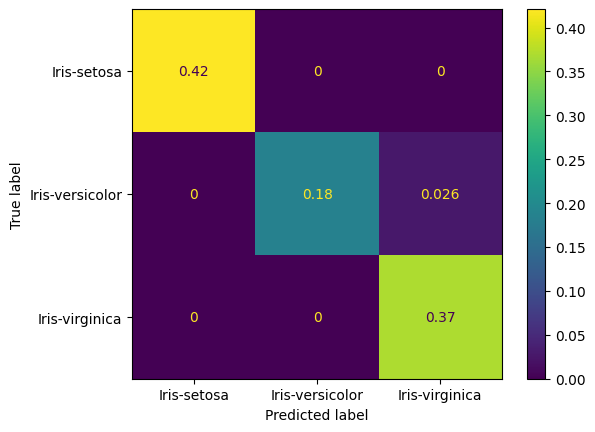

In [10]:
# Compute confusion matrix
cm_svm = confusion_matrix(y_test, predict_svm, labels=svm.classes_) / len(y_test)

# Plot confusion matrix
plot_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                               display_labels=svm.classes_)
plot_svm.plot()
plt.show()

<font size = "5">

Evaluate SVM performance

In [11]:
# List performance metrics
list_scorers =  pd.DataFrame(get_scorer_names())
list_scorers

,0
0,accuracy
1,adjusted_mutual_info_score
2,adjusted_rand_score
3,average_precision
4,balanced_accuracy
5,completeness_score
6,d2_absolute_error_score
7,explained_variance
8,f1
9,f1_macro


In [12]:
# Compute the cross-validated error
metrics_svm = cross_validate(SVC(), X_train_scale, y_train,
                     scoring=["accuracy", "precision_macro", "recall_macro"],
                     return_train_score=False, cv=3)
display(pd.DataFrame(metrics_svm))

/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro
0,0.007394,0.030154,0.973684,0.977778,0.972222
1,0.011006,0.025774,0.972973,0.974359,0.976190
2,0.003409,0.087153,0.945946,0.948413,0.948413


In [13]:
# Summarize mean across folds
pd.DataFrame(metrics_svm).mean()

fit_time                0.007270
score_time              0.047694
test_accuracy           0.964201
test_precision_macro    0.966850
test_recall_macro       0.965608
dtype: float64

# <span style="color:darkblue"> **Part 2 Random Forests** </span>

<font size = "5">

In part 2, I used a `RandomForestClassifier` which aggregates multiple decision trees built on random feature and sample subsets.

I evaluated model performance using 3-fold cross-validation with the same metrics, accuracy, precision, and recall to assess model.

I used `GridSearchCV` to explore opyimal parameter (`n_estimators`,` learning_rate`, `max_depth`).

Coding rationale: 
- I use `RandomForestClassifier` rather than `RandomForestRegressor` because the target is not numerical values but categorical labels.
- I apply `LabelEncoder()` to transform string labels into integer codes because scikit-learn’s classifiers require the target variable y to be numeric.

In [91]:
# Encode labels
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train.values.ravel())
y_test_enc  = encoder.transform(y_test.values.ravel())


In [92]:
# Estimate random forest
rf_model = RF(random_state=123)
rf_model.fit(X_train_scale, y_train_enc)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<font size = "5">

Evaluate the Random Forest model's performance

In [93]:
metrics_rf = cross_validate(rf_model, X_train_scale, y_train_enc,
                            scoring=["accuracy", "precision_macro", "recall_macro"],
                            return_train_score=False, cv=3)

display(pd.DataFrame(metrics_rf))

,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro
0,0.204977,0.017527,1.000000,1.000000,1.000000
1,0.168526,0.017004,0.891892,0.896825,0.896825
2,0.170679,0.013119,0.891892,0.904167,0.892857


In [29]:
# Summarize mean across folds
pd.DataFrame(metrics_rf).mean()

fit_time                0.188696
score_time              0.011933
test_accuracy           0.927928
test_precision_macro    0.933664
test_recall_macro       0.929894
dtype: float64

In [ ]:
param_grid = {
    "n_estimators": [5, 10, 15, 20, 30],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5]
}

grid_search = GridSearchCV(
    estimator=GBC(random_state=0),
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    return_train_score=False
)

grid_search.fit(X_train_scale, y_train_enc)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated Accuracy:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 15}
Best Cross-Validated Accuracy: 0.9279279279279279


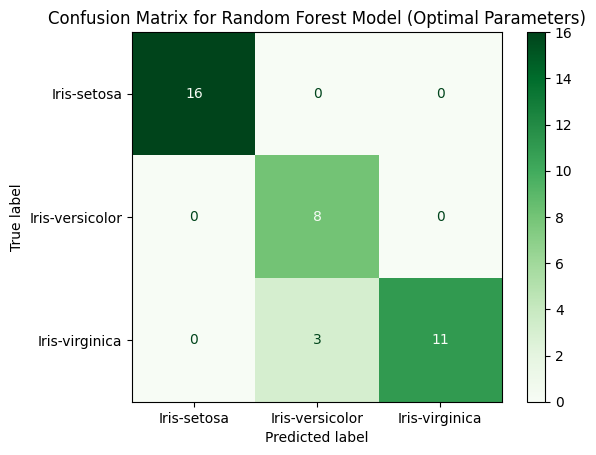

In [95]:
# predict with optimal parameters
best_model = grid_search.best_estimator_
pred_rf = best_model.predict(X_test_scale)

# draw confusion matrix
cm_rf = confusion_matrix(y_test_enc, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=encoder.classes_)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix for Random Forest Model (Optimal Parameters)")
plt.show()

# <span style="color:darkblue"> **Part 3 Neural Networks** </span>

<font size = "5">

I defined a neural network model to predict flower classes. The model includes an input layer with 16 units and a softmax output layer that converts the network’s outputs into class probabilities. I used the Adam optimizer with a learning rate of 0.001 for efficient optimization.

Coding rationale:

- I used the `softmax` activation in the output layer as it can turn the model’s outputs into probabilities for each class.
- I used the `Sparse Categorical Cross-Entropy` in the Loss Function that could handle integer labels and measures how far the model’s predicted probabilities are from the true class.
- I wrapped the neural network model in a `KerasClassifier` object so it can be recognized by the scikit-learn’s `cross_validate()` function.
- I also redefined a separate neural network model to make k-folds cross-validation possible. For each fold, the model would be trained from beginning on that fold’s training data and then evaluated on unseen test data.


In [73]:
# configuration set-up for neural networks model
neu_model = keras.models.Sequential()

# input layer
neu_model.add(Dense(units=16, activation='relu', input_shape=(k_features,)))

#output layer
neu_model.add(Dense(units=3, activation='softmax'))

# Define an optimizer
adam = keras.optimizers.Adam(learning_rate=0.001)

# Define loss function to optimize
neu_model.compile(loss='sparse_categorical_crossentropy', optimizer=adam, metrics=["accuracy"])

# Set random seed
tf.keras.utils.set_random_seed(0)  

# Train model
neu_model.fit(X_train_scale, y_train_enc, epochs=100)

/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4286 - loss: 1.0863 
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4643 - loss: 1.0550
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 1.0254
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5089 - loss: 0.9970
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5179 - loss: 0.9697
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5357 - loss: 0.9436
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5357 - loss: 0.9185
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5536 - loss: 0.8946
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5714 - loss: 0.8717
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5893 - loss: 0.8497 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6250 - loss: 0.8284
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6696 - 

<font size = "5">

Evaluate the Neural Network model's performance

In [77]:
# Define a function to build the neural network model
def build_model():
    model = keras.models.Sequential()
    model.add(Dense(16, activation='relu', input_shape=(k_features,)))
    model.add(Dense(3, activation='softmax'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

#Wrap the Keras model 
neu_model = KerasClassifier(model=build_model, epochs=100, batch_size=16, verbose=0)

# Perform 3-fold cross-validation
metrics_neu = cross_validate(
    neu_model,
    X_train_scale,
    y_train_enc,
    scoring=["accuracy", "precision_macro", "recall_macro"],
    return_train_score=False,
    cv=3
)

display(pd.DataFrame(metrics_neu))


/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the m

,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro
0,5.843521,0.124944,0.947368,0.952137,0.944056
1,5.832761,0.125079,0.864865,0.848485,0.863095
2,5.959649,0.180185,0.918919,0.931746,0.931746


In [70]:
# Summarize mean across folds
pd.DataFrame(metrics_neu).mean()

fit_time                6.320386
score_time              0.136377
test_accuracy           0.919867
test_precision_macro    0.925309
test_recall_macro       0.920706
dtype: float64

/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


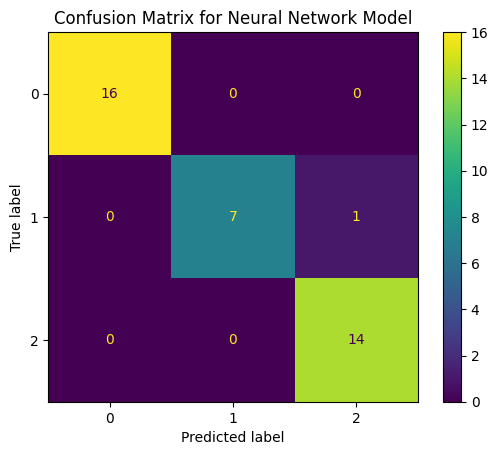

In [79]:
# Rebuild and train model on the full training data
final_model = build_model()
final_model.fit(X_train_scale, y_train_enc, epochs=100, batch_size=16, verbose=0)

# Predict probabilities on test data
predicted_prob = final_model.predict(X_test_scale)

# Convert to predicted classes (0, 1, 2)
predicted_class = np.argmax(predicted_prob, axis=1)

#Draw confusion matrix
cm_neu = confusion_matrix(y_test_enc, predicted_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_neu)
disp.plot()
plt.title("Confusion Matrix for Neural Network Model")
plt.show()


# <span style="color:darkblue"> **Part 4 Ridge Logistic Regression** </span>

<font size = "5">

Coding rationale:

- I chose ridge-regularized logistic regression because the prediction target is categorical.

In [87]:
# define L2-regularized multinomial logistic regression
ridge_logit = LogisticRegression(
    penalty='l2',
    C=1.0,
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

<font size = "5">

Evaluate the Reige logistic model's performance

In [88]:
# cross validation
metrics_ridge = cross_validate(
    ridge_logit,
    X_train_scale,
    y_train_enc,
    scoring=["accuracy", "precision_macro", "recall_macro"],
    cv=3,
    return_train_score=False
)

display(pd.DataFrame(metrics_ridge))


/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro
0,0.043904,0.011307,1.000000,1.000000,1.000000
1,0.004262,0.005126,0.918919,0.923077,0.924603
2,0.004827,0.005319,0.945946,0.948413,0.948413


In [89]:
display(pd.DataFrame(metrics_ridge).mean())

fit_time                0.017664
score_time              0.007251
test_accuracy           0.954955
test_precision_macro    0.957163
test_recall_macro       0.957672
dtype: float64

/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


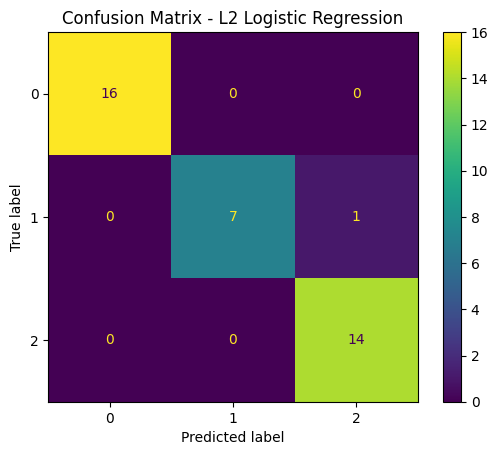

In [ ]:
# Train final ridge logistic model on full training data
ridge_logit.fit(X_train_scale, y_train_enc)

# Predict test
y_pred_ridge = ridge_logit.predict(X_test_scale)

# draw confusion matrix
cm_ridge = confusion_matrix(y_test_enc, y_pred_ridge)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_ridge)
disp.plot()
plt.title("Confusion Matrix for L2 Logistic Regression")
plt.show()

# <span style="color:darkblue"> **Summarize Findings** </span>

<font size = "4">




In [ ]:
# Compute mean score from each models' evaluation metrics
svm_mean = pd.DataFrame(metrics_svm).mean()
rf_mean = pd.DataFrame(metrics_rf).mean()
neu_mean = pd.DataFrame(metrics_neu).mean()
ridge_mean = pd.DataFrame(metrics_ridge).mean()

# Combine into a comparison DataFrame
metrics_table = pd.DataFrame({
    "Model": [
        "Support Vector Machine (SVM)",
        "Random Forest Classifier",
        "Neural Network (Keras)",
        "Ridge Logistic Regression"
    ],
    "Accuracy": [
        svm_mean["test_accuracy"],
        rf_mean["test_accuracy"],
        neu_mean["test_accuracy"],
        ridge_mean["test_accuracy"]
    ],
    "Precision (Macro)": [
        svm_mean["test_precision_macro"],
        rf_mean["test_precision_macro"],
        neu_mean["test_precision_macro"],
        ridge_mean["test_precision_macro"]
    ],
    "Recall (Macro)": [
        svm_mean["test_recall_macro"],
        rf_mean["test_recall_macro"],
        neu_mean["test_recall_macro"],
        ridge_mean["test_recall_macro"]
    ]
})

# Round to 4 decimals
metrics_table = metrics_table.round(4)

# Display table
display(
    metrics_table.style
    .set_caption("Model Performance Comparison on Iris Dataset")
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]}
    ])
    .background_gradient(cmap="YlGnBu", subset=["Accuracy", "Precision (Macro)", "Recall (Macro)"])
)


,Model,Accuracy,Precision (Macro),Recall (Macro)
0,Support Vector Machine (SVM),0.964200,0.966800,0.965600
1,Random Forest Classifier,0.927900,0.933700,0.929900
2,Neural Network (Keras),0.910400,0.910800,0.913000
3,Ridge Logistic Regression,0.955000,0.957200,0.957700


<font size = "5">

**Disscussion**

All four models have achieved high classification accuracy on the Iris dataset, demonstrating that the dataset is relatively well-separated and suitable for most standard supervised learning algorithms.

Among them, the Support Vector Machine (SVM) achieved the highest overall performance across all metrics, with an average accuracy of 0.9642, precision of 0.9668, and recall of 0.9656. This indicates that SVM effectively identified class boundaries and generalized well across folds.

The Ridge Logistic Regression model also performed competitively, with an accuracy of 0.9550, suggesting that a linear decision boundary with regularization was sufficient to handle most separable patterns in the data.

In contrast, the Random Forest classifier obtained slightly lower scores, even after searching for optimal parameters. The Neural Network also showed a low accuracy (0.9104), which is expected for a small dataset, as deep learning models typically require more data to achieve stable generalization.